<a href="https://colab.research.google.com/github/K26J/CatVsDogImageClassificationusingCNN/blob/main/Dogs_Vs_Cats_CNNProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Setting the new Kaggle API Token from your screenshot
os.environ['KAGGLE_API_TOKEN'] = "KGAT_f668baebb900ac147f92e819a321bca4"

print("New API Token configured!")

New API Token configured!


In [ ]:
# Download the dataset
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:06<00:00, 171MB/s]



In [ ]:
import zipfile
zip_ref= zipfile.ZipFile('/content/dogsvscats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

# Importing Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, AveragePooling2D, Flatten, BatchNormalization, Dropout
from keras.regularizers import l2
from keras.callbacks import EarlyStopping


# Loading Data Using Generator

In [ ]:
train_ds= keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

Found 20000 files belonging to 2 classes.


In [ ]:
test_ds= keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

Found 5000 files belonging to 2 classes.


# Normalization to convert pixel values of each image between 0-1


In [ ]:
def process(image, label):
  image= tf.cast(image/255. , tf.float32)
  return image, label

train_ds= train_ds.map(process)
test_ds= test_ds.map(process)

# Defining Model

In [ ]:
model= Sequential()

# 1. The Foundation Blueprint (The Fix!)
model.add(Input(shape=(256, 256, 3)))

model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size= (2,2), strides= 2, padding= 'same'))

model.add(Conv2D(64, kernel_size= (3,3), padding= 'same', activation= 'relu', kernel_regularizer=L2(0.0001)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size= (2,2), strides= 2, padding= 'same'))

model.add(Conv2D(128, kernel_size= (3,3), padding= 'same', activation= 'relu'))
model.add(BatchNormalization())
model.add(AveragePooling2D(pool_size= (2,2), strides= 2, padding= 'same'))

model.add(Conv2D(256, kernel_size= (3,3), padding= 'same', activation= 'relu'))
model.add(AveragePooling2D(pool_size= (2,2), strides= 1, padding= 'same'))

model.add(Flatten())

model.add(Dense(128, activation= 'relu'))
model.add(Dense(64, activation= 'relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation= 'relu'))
model.add(Dense(1, activation= 'sigmoid'))



In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 32, 32, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 32, 32, 256)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 262144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │    33,554,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,954,241 (129.53 MB)

 Trainable params: 33,953,793 (129.52 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer= 'adam', loss= 'binary_crossentropy', metrics= ['accuracy'])

In [ ]:
early_stopping= EarlyStopping(
    monitor= 'val_accuracy',
    patience= 5,
    mode= 'max',
    restore_best_weights= True
)

In [ ]:
history= model.fit(train_ds, epochs= 50, callbacks= early_stopping, validation_data= test_ds)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.6872 - loss: 0.8411 - val_accuracy: 0.7276 - val_loss: 0.5356
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 99ms/step - accuracy: 0.7808 - loss: 0.4738 - val_accuracy: 0.7534 - val_loss: 0.5264
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 105ms/step - accuracy: 0.8364 - loss: 0.3829 - val_accuracy: 0.8234 - val_loss: 0.4032
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 98ms/step - accuracy: 0.8757 - loss: 0.3021 - val_accuracy: 0.8652 - val_loss: 0.3374
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.9094 - loss: 0.2294 - val_accuracy: 0.8476 - val_loss: 0.3729
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.9351 - loss: 0.1718 - val_accuracy: 0.8588 - val_loss: 0.4314
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.9513 - loss: 0.1371 - val_accuracy: 0.8540 - val_loss: 0.6631
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.9677 - loss: 0.100

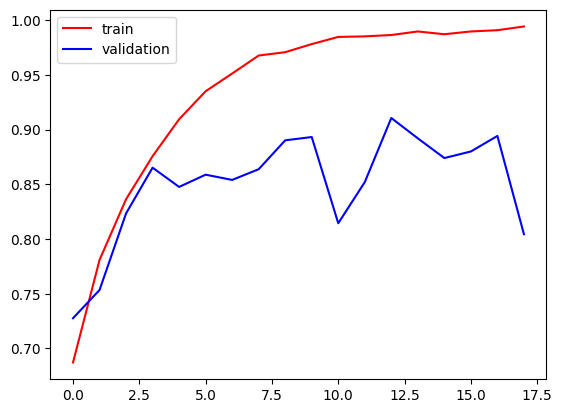

In [ ]:
# plotting graph
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color= 'red', label= 'train')
plt.plot(history.history['val_accuracy'], color= 'blue', label= 'validation')
plt.legend()
plt.show()

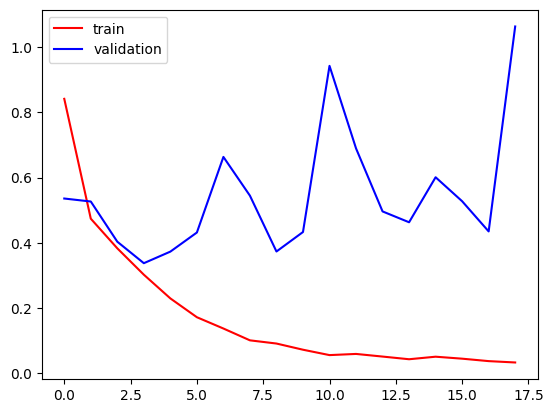

In [ ]:
plt.plot(history.history['loss'], color= 'red', label= 'train')
plt.plot(history.history['val_loss'], color= 'blue', label= 'validation')
plt.legend()
plt.show()


In [ ]:
print("Weights restored from Epoch:", early_stopping.best_epoch + 1)

Weights restored from Epoch: 13


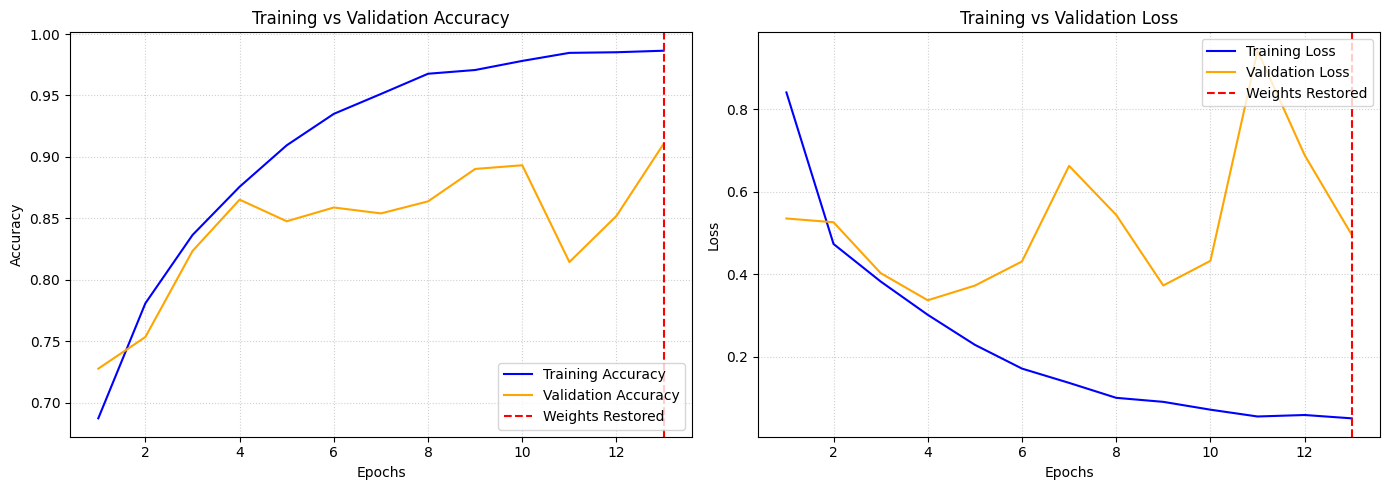

In [ ]:
import matplotlib.pyplot as plt

# 1. Define your cut-off point
# (We add 1 because Keras tracks the best_epoch internally starting at index 0)
best_epoch_num = early_stopping.best_epoch + 1

# 2. Extract and slice the data arrays
# The syntax [:best_epoch_num] grabs everything from the start up to our target
acc = history.history['accuracy'][:best_epoch_num]
val_acc = history.history['val_accuracy'][:best_epoch_num]

loss = history.history['loss'][:best_epoch_num]
val_loss = history.history['val_loss'][:best_epoch_num]

# Create an array of epoch numbers (1 to 13) for a clean X-axis
epochs_range = range(1, best_epoch_num + 1)

# 3. Create the Visualizations
plt.figure(figsize=(14, 5))

# --- Plot 1: Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
# Adding a vertical marker to show this is the exact restoration point
plt.axvline(x=best_epoch_num, color='red', linestyle='--', label='Weights Restored')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.axvline(x=best_epoch_num, color='red', linestyle='--', label='Weights Restored')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Display the final dashboard
plt.tight_layout()
plt.show()

# Testing the model on unseen data

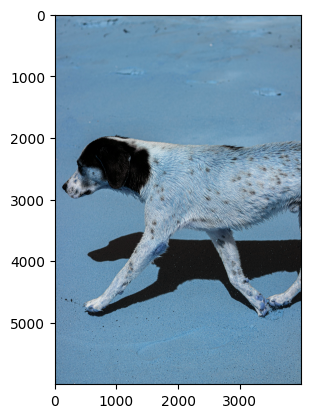

In [ ]:
import cv2
test_image= cv2.imread('/content/Dog_test_image.jpg')
plt.imshow(test_image)

In [ ]:
test_image.shape

(6000, 4000, 3)

In [ ]:
test_image= cv2.resize(test_image, (256, 256))

In [ ]:
test_input= test_image.reshape((1, 256, 256, 3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[1.]], dtype=float32)